# Log vs Snapshot Alignment Analysis

This notebook analyzes how log time stamps align with snapshot times, focusing on: duplicate time values, gaps larger than snapshot spacing, and the impact of approximating accretion rates using log time directly.

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to sys.path so local modules are importable
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from raw_data_processing.parse_log_file import load_config, parse_logfile

%matplotlib inline

In [156]:
# Select a target simulation
gal_type = "disk_galaxy"  # or "elliptical_galaxy"
gal_nickname = "low"  # see .config/RawDataConfig.json

configs_dir = os.path.join(project_root, ".config")
configs = load_config(configs_dir)
raw_cfg = configs["RawDataConfig"][gal_type][gal_nickname]
hdfra_cfg = configs["HdfraConfig"][gal_type]
base_cfg = configs["BaseConfig"]

gal_name = f"{gal_type}_{gal_nickname}"
raw_dir = base_cfg["raw_data_dir"]
data_dir = base_cfg["data_dir"]
log_path = os.path.join(raw_dir, raw_cfg["folder_name"], raw_cfg["log_file"])
parquet_path = os.path.join(data_dir, f"{gal_name}.parquet")

print("Log file:", log_path)
print("Parquet cache:", parquet_path)
print("Snapshot dt:", raw_cfg["snapshot_dt"])

Log file: D:/PersonFiles/Codes/Project/MACNet v1/RawData\DiskGalaxy_Low\trial_55_low.log
Parquet cache: D:/PersonFiles/Codes/Project/MACNet v1/Data\disk_galaxy_low.parquet
Snapshot dt: 0.0125


In [157]:
def get_snapshot_times(cfg):
    snapshot_dt = cfg["snapshot_dt"]
    offset = cfg.get("offset", 0.0)
    if cfg.get("mode") == "concatenate":
        indices = np.concatenate([np.arange(start, end) for start, end in cfg["ranges"]])
    else:
        start, end = cfg["range"]
        indices = np.arange(start, end)
    return offset + indices * snapshot_dt

def load_log_df(log_path, colnames, parquet_path=None, force_parse=False):
    if parquet_path and os.path.exists(parquet_path) and not force_parse:
        return pd.read_parquet(parquet_path)
    return parse_logfile(path=log_path, colnames=colnames, save_path=parquet_path, force_parse=force_parse)

def alignment_stats(times, snapshot_times, scope):
    t_sorted = np.sort(times)
    left = np.searchsorted(t_sorted, snapshot_times - scope, side="left")
    right = np.searchsorted(t_sorted, snapshot_times + scope, side="right")
    counts = right - left

    nearest = np.empty_like(snapshot_times, dtype=float)
    for i, s in enumerate(snapshot_times):
        idx = np.searchsorted(t_sorted, s)
        candidates = []
        if idx < len(t_sorted):
            candidates.append(abs(t_sorted[idx] - s))
        if idx > 0:
            candidates.append(abs(t_sorted[idx - 1] - s))
        nearest[i] = min(candidates) if candidates else np.nan

    missing = counts == 0
    return counts, nearest, missing

def duplicate_stats(times):
    s = pd.Series(times)
    vc = s.value_counts()
    dup = vc[vc > 1]
    total = len(s)
    dup_rows = int(dup.sum())
    return {
        "total_rows": total,
        "unique_times": int(vc.size),
        "dup_rows": dup_rows,
        "dup_ratio": dup_rows / total if total else 0.0,
        "max_multiplicity": int(dup.max()) if not dup.empty else 1,
    }

In [158]:
# Load log data
df = load_log_df(log_path, hdfra_cfg["colnames"], parquet_path=parquet_path, force_parse=False)
df = df.dropna(subset=["time"]).copy()

snapshot_times = get_snapshot_times(raw_cfg)
snapshot_dt = raw_cfg["snapshot_dt"]

print("Rows in log:", len(df))
print("Snapshots:", len(snapshot_times))
print("Time range in log:", df["time"].min(), "to", df["time"].max())
print("Time range of snapshots:", snapshot_times.min(), "to", snapshot_times.max())

Rows in log: 3268423
Snapshots: 1000
Time range in log: 0.0 to 12.487
Time range of snapshots: 0.0 to 12.4875


In [159]:
# 1) Duplicate time values (exact)
t = df["time"].to_numpy(dtype=float)
exact_stats = duplicate_stats(t)

display(pd.DataFrame([exact_stats]))

,total_rows,unique_times,dup_rows,dup_ratio,max_multiplicity
0,3268423,106566,3236067,0.9901,784463


In [160]:
# 2) Gaps larger than snapshot spacing
t_sorted = np.sort(t)
gaps = np.diff(t_sorted)
big_gaps = gaps[gaps > snapshot_dt]

print("Total gaps:", len(gaps))
print("Gaps > snapshot_dt:", len(big_gaps))
if len(gaps) > 0:
    print("Ratio of large gaps:", len(big_gaps) / len(gaps))
    print("Max gap:", gaps.max())

Total gaps: 3268422
Gaps > snapshot_dt: 0
Ratio of large gaps: 0.0
Max gap: 0.0010000000000012221


In [161]:
# 3) Alignment counts for different windows
scopes = {
    "0.5_dt": 0.5 * snapshot_dt,
    "0.4_dt": 0.4 * snapshot_dt,
    "0.3_dt": 0.3 * snapshot_dt,
    "0.2_dt": 0.2 * snapshot_dt,
    "0.1_dt": 0.1 * snapshot_dt,
    "0.05_dt": 0.05 * snapshot_dt,
    "0.02_dt": 0.02 * snapshot_dt,
    "0.01_dt": 0.01 * snapshot_dt,
    "0.005_dt": 0.005 * snapshot_dt,
}

rows = []
for label, scope in scopes.items():
    counts, nearest, missing = alignment_stats(t, snapshot_times, scope)
    rows.append({
        "scope": label,
        "missing_snapshots": int(missing.sum()),
        "missing_ratio": float(missing.mean()),
        "min_count": int(counts.min()) if len(counts) else 0,
        "max_count": int(counts.max()) if len(counts) else 0,
        "median_count": float(np.median(counts)) if len(counts) else 0.0,
        "nearest_max": float(np.max(nearest)) if len(nearest) else 0.0,
        "nearest_median": float(np.median(nearest)) if len(nearest) else 0.0,
    })

display(pd.DataFrame(rows))

,scope,missing_snapshots,missing_ratio,min_count,max_count,median_count,nearest_max,nearest_median
0,0.5_dt,0,0.000,13,804206,450.0,0.0005,0.0
1,0.4_dt,0,0.000,10,802094,354.5,0.0005,0.0
2,0.3_dt,0,0.000,8,792302,252.0,0.0005,0.0
3,0.2_dt,0,0.000,5,786130,166.5,0.0005,0.0
4,0.1_dt,0,0.000,2,13379,76.5,0.0005,0.0
5,0.05_dt,0,0.000,1,9361,39.0,0.0005,0.0
6,0.02_dt,117,0.117,0,5072,13.5,0.0005,0.0
7,0.01_dt,135,0.135,0,3523,9.0,0.0005,0.0
8,0.005_dt,181,0.181,0,1996,3.0,0.0005,0.0


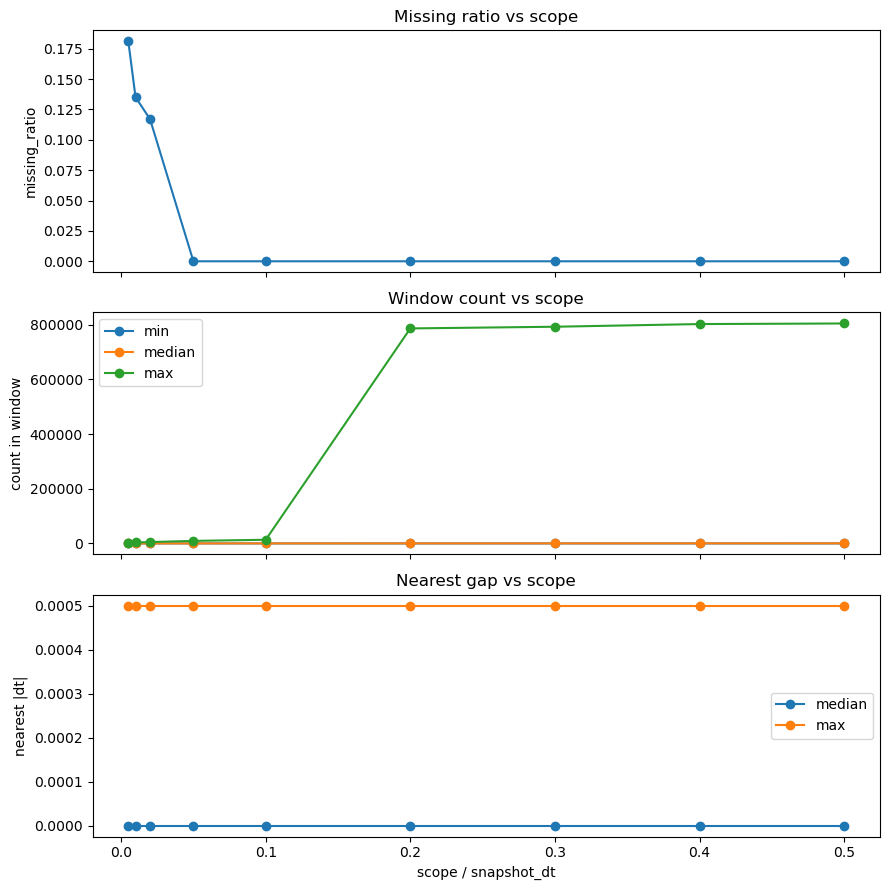

In [162]:
# 3b) Visualize how stats change with scope
stats_df = pd.DataFrame(rows).copy()
stats_df["scope_value"] = stats_df["scope"].str.replace("_dt", "", regex=False).astype(float)
stats_df = stats_df.sort_values("scope_value")

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(stats_df["scope_value"], stats_df["missing_ratio"], marker="o")
axes[0].set_ylabel("missing_ratio")
axes[0].set_title("Missing ratio vs scope")

axes[1].plot(stats_df["scope_value"], stats_df["min_count"], marker="o", label="min")
axes[1].plot(stats_df["scope_value"], stats_df["median_count"], marker="o", label="median")
axes[1].plot(stats_df["scope_value"], stats_df["max_count"], marker="o", label="max")
axes[1].set_ylabel("count in window")
axes[1].set_title("Window count vs scope")
axes[1].legend()

axes[2].plot(stats_df["scope_value"], stats_df["nearest_median"], marker="o", label="median")
axes[2].plot(stats_df["scope_value"], stats_df["nearest_max"], marker="o", label="max")
axes[2].set_xlabel("scope / snapshot_dt")
axes[2].set_ylabel("nearest |dt|")
axes[2].set_title("Nearest gap vs scope")
axes[2].legend()

plt.tight_layout()

In [163]:
# 4) Compare time column vs cumulative dt (disk_galaxy has dt)
if "dt" in df.columns:
    dt = df["dt"].to_numpy(dtype=float)
    t0 = float(df["time"].iloc[0])
    t_from_dt = t0 + np.cumsum(np.r_[0.0, dt[:-1]])
    diff = t_from_dt - t

    print("Time vs cumulative dt (t_from_dt - time) stats:")
    print("  mean:", float(np.mean(diff)))
    print("  std :", float(np.std(diff)))
    print("  max :", float(np.max(diff)))
    print("  min :", float(np.min(diff)))

    stagnant = np.sum(np.diff(t) <= 0)
    print("Non-increasing time steps:", int(stagnant))
else:
    print("No dt column in this log; skipping cumulative dt comparison.")

Time vs cumulative dt (t_from_dt - time) stats:
  mean: -8.737112631668872
  std : 2.4343555740715757
  max : 0.0
  min : -12.36216286204315
Non-increasing time steps: 3161857


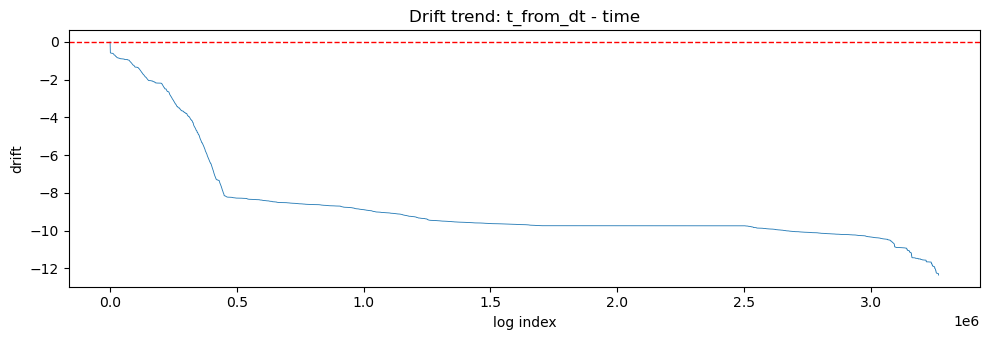

In [164]:
# 4b) Drift trend plot (t_from_dt - time)
if "dt" in df.columns:
    dt = df["dt"].to_numpy(dtype=float)
    t0 = float(df["time"].iloc[0])
    t_from_dt = t0 + np.cumsum(np.r_[0.0, dt[:-1]])
    diff = t_from_dt - df["time"].to_numpy(dtype=float)

    plt.figure(figsize=(10, 3.5))
    plt.plot(diff, lw=0.6)
    plt.axhline(0.0, color="red", linestyle="--", linewidth=1)
    plt.title("Drift trend: t_from_dt - time")
    plt.xlabel("log index")
    plt.ylabel("drift")
    plt.tight_layout()
else:
    print("No dt column in this log; skipping drift trend plot.")

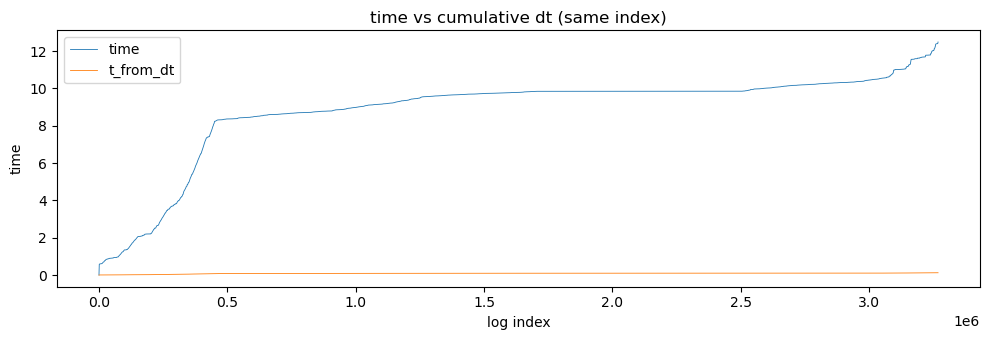

In [165]:
# 4c) Compare time vs cumulative dt (same index)
if "dt" in df.columns:
    dt = df["dt"].to_numpy(dtype=float)
    t0 = float(df["time"].iloc[0])
    t_from_dt = t0 + np.cumsum(np.r_[0.0, dt[:-1]])
    t_time = df["time"].to_numpy(dtype=float)

    plt.figure(figsize=(10, 3.5))
    plt.plot(t_time, lw=0.6, label="time")
    plt.plot(t_from_dt, lw=0.6, label="t_from_dt")
    plt.title("time vs cumulative dt (same index)")
    plt.xlabel("log index")
    plt.ylabel("time")
    plt.legend()
    plt.tight_layout()
else:
    print("No dt column in this log; skipping time vs cumulative dt plot.")

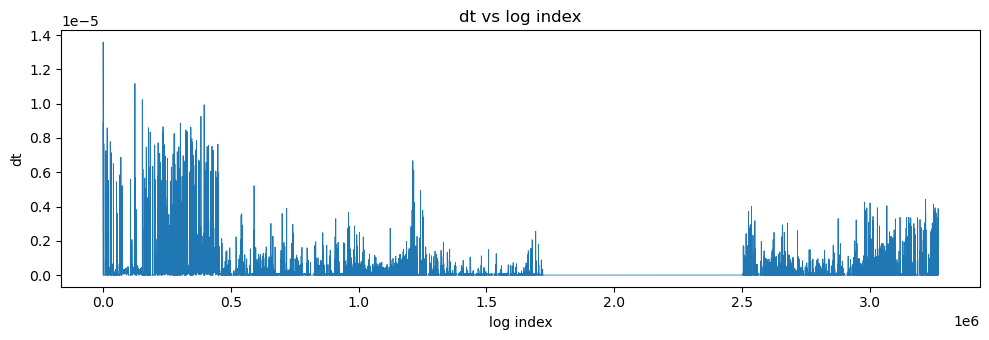

In [166]:
# 4d) dt vs log index
if "dt" in df.columns:
    dt = df["dt"].to_numpy(dtype=float)
    plt.figure(figsize=(10, 3.5))
    plt.plot(dt, lw=0.6)
    plt.title("dt vs log index")
    plt.xlabel("log index")
    plt.ylabel("dt")
    plt.tight_layout()
else:
    print("No dt column in this log; skipping dt plot.")

time min/max: 0.0 12.487
dt min/max: 2.8954e-15 1.3603e-05


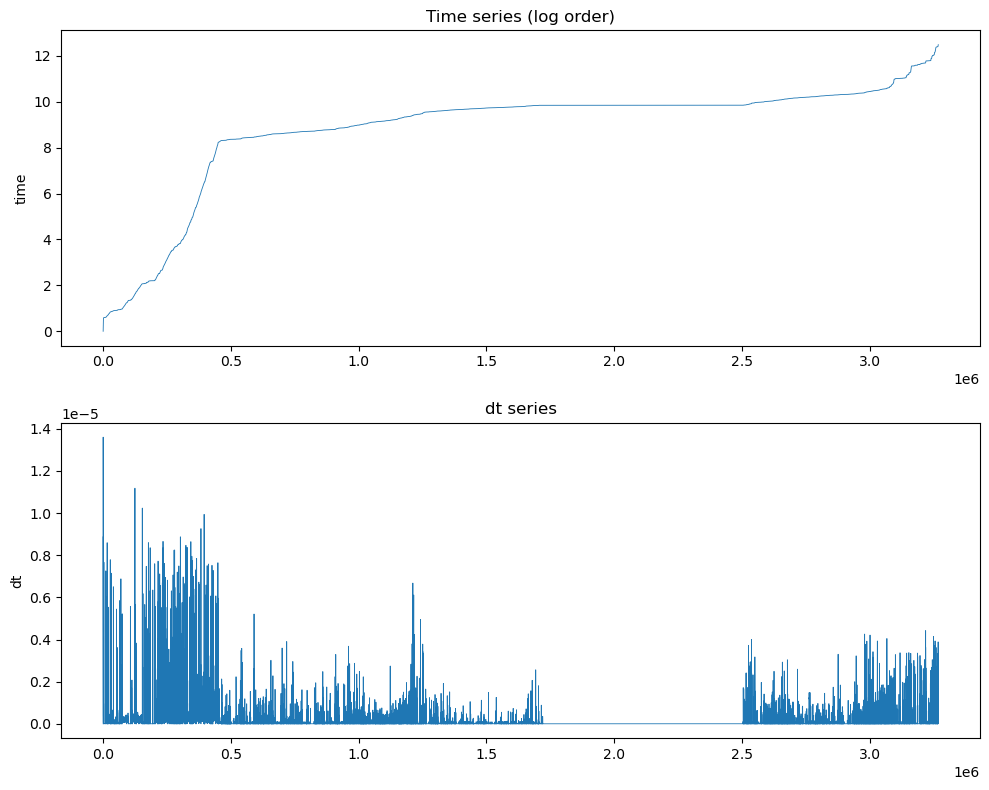

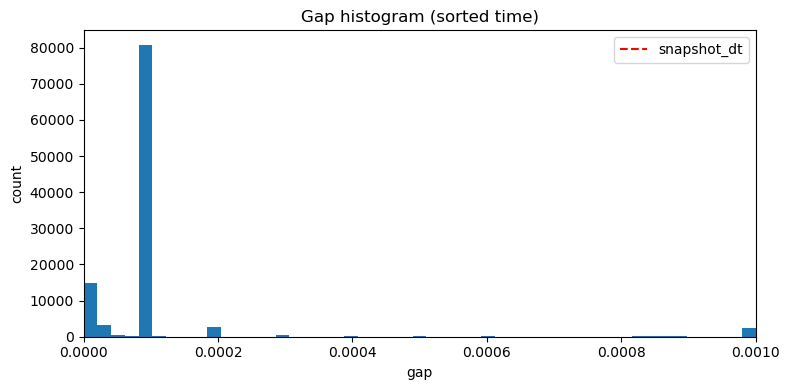

In [167]:
print("time min/max:", np.nanmin(t), np.nanmax(t))
if "dt" in df.columns:
    print("dt min/max:", np.nanmin(df["dt"]), np.nanmax(df["dt"]))

# 5) Plots (separate x-axes for time/dt)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(t, lw=0.6)
axes[0].set_ylabel("time")
axes[0].set_title("Time series (log order)")

if "dt" in df.columns:
    axes[1].plot(df["dt"].to_numpy(dtype=float), lw=0.6)
    axes[1].set_ylabel("dt")
    axes[1].set_title("dt series")
else:
    axes[1].plot(np.diff(np.sort(t)), lw=0.6)
    axes[1].set_ylabel("time gap")
    axes[1].set_title("Sorted time gaps")

plt.tight_layout()

# 5a) Gap histogram (sorted time)
gaps_sorted = np.diff(np.sort(t))
gaps_sorted = gaps_sorted[gaps_sorted > 0]
plt.figure(figsize=(8, 4))
if len(gaps_sorted) > 0:
    # Focus on main mass of gaps to avoid one huge outlier flattening the histogram
    hi = np.percentile(gaps_sorted, 99.5)
    bins = np.linspace(0, hi, 50)
    plt.hist(gaps_sorted, bins=bins)
    plt.axvline(snapshot_dt, color="red", linestyle="--", label="snapshot_dt")
    plt.xlim(0, hi)
else:
    plt.text(0.5, 0.5, "No positive gaps", ha="center", va="center")

plt.ylabel("count")
plt.xlabel("gap")
plt.title("Gap histogram (sorted time)")
plt.legend()
plt.tight_layout()

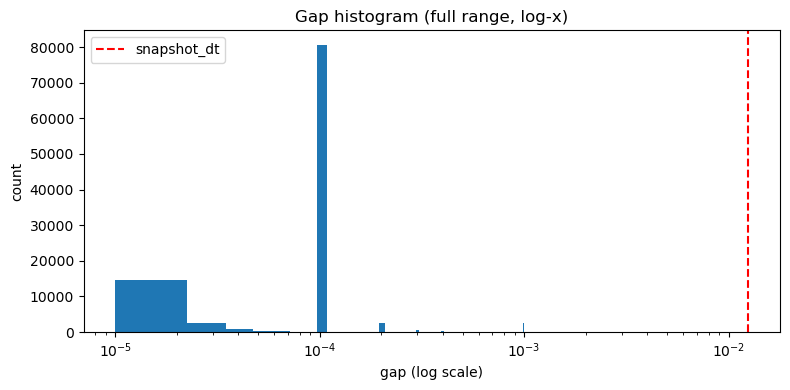

In [168]:
# 5b) Full-range gap histogram with log-x axis
gaps_full = np.diff(np.sort(t))
gaps_full = gaps_full[gaps_full > 0]
if len(gaps_full) > 0:
    plt.figure(figsize=(8, 4))
    plt.hist(gaps_full, bins=80)
    plt.xscale("log")
    plt.axvline(snapshot_dt, color="red", linestyle="--", label="snapshot_dt")
    plt.title("Gap histogram (full range, log-x)")
    plt.xlabel("gap (log scale)")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
else:
    print("No positive gaps; skipping full-range histogram.")

In [169]:
# 6) Text summary to support interpretation
def format_ratio(x):
    return f"{x * 100:.2f}%"

def summarize(exact_stats, gaps, snapshot_dt, scopes, df):
    lines = []
    lines.append(f"Exact duplicate time rows: {exact_stats['dup_rows']} of {exact_stats['total_rows']} ({format_ratio(exact_stats['dup_ratio'])})")
    lines.append(f"Max multiplicity (exact): {exact_stats['max_multiplicity']}")

    if len(gaps) > 0:
        big = gaps[gaps > snapshot_dt]
        lines.append(f"Gaps > snapshot_dt: {len(big)} of {len(gaps)} ({format_ratio(len(big)/len(gaps))})")
        lines.append(f"Max gap: {gaps.max()}")

    for label, scope in scopes.items():
        counts, nearest, missing = alignment_stats(df['time'].to_numpy(), snapshot_times, scope)
        lines.append(
            f"Window {label} (scope={scope}): missing {int(missing.sum())} of {len(missing)} ({format_ratio(float(missing.mean()))})"
        )
        lines.append(f"  Median window count: {np.median(counts):.2f}; max count: {np.max(counts)}")
        lines.append(f"  Median nearest |dt|: {np.median(nearest):.3e}; max nearest |dt|: {np.max(nearest):.3e}")

    if 'dt' in df.columns:
        dt = df['dt'].to_numpy(dtype=float)
        t0 = float(df['time'].iloc[0])
        t_from_dt = t0 + np.cumsum(np.r_[0.0, dt[:-1]])
        diff = t_from_dt - df['time'].to_numpy(dtype=float)
        lines.append(f"Cumulative dt drift: mean={np.mean(diff):.3e}, std={np.std(diff):.3e}, max={np.max(diff):.3e}")

    return "\n".join(lines)

print(summarize(exact_stats, gaps, snapshot_dt, scopes, df))

Exact duplicate time rows: 3236067 of 3268423 (99.01%)
Max multiplicity (exact): 784463
Gaps > snapshot_dt: 0 of 3268422 (0.00%)
Max gap: 0.0010000000000012221
Window 0.5_dt (scope=0.00625): missing 0 of 1000 (0.00%)
  Median window count: 450.00; max count: 804206
  Median nearest |dt|: 0.000e+00; max nearest |dt|: 5.000e-04
Window 0.4_dt (scope=0.005000000000000001): missing 0 of 1000 (0.00%)
  Median window count: 354.50; max count: 802094
  Median nearest |dt|: 0.000e+00; max nearest |dt|: 5.000e-04
Window 0.3_dt (scope=0.00375): missing 0 of 1000 (0.00%)
  Median window count: 252.00; max count: 792302
  Median nearest |dt|: 0.000e+00; max nearest |dt|: 5.000e-04
Window 0.2_dt (scope=0.0025000000000000005): missing 0 of 1000 (0.00%)
  Median window count: 166.50; max count: 786130
  Median nearest |dt|: 0.000e+00; max nearest |dt|: 5.000e-04
Window 0.1_dt (scope=0.0012500000000000002): missing 0 of 1000 (0.00%)
  Median window count: 76.50; max count: 13379
  Median nearest |dt|: 